# Final Project
#
- Anna Ikeda
- Alfonso Garcia
- Erick Espinoza

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)


In [ ]:
df = pd.read_csv("bank-additional.csv", sep=';')

In [3]:
# Display first 10 rows of the dataframe
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
5,32,services,single,university.degree,no,no,no,cellular,sep,thu,...,3,999,2,failure,-1.1,94.199,-37.5,0.884,4963.6,no
6,32,admin.,single,university.degree,no,yes,no,cellular,sep,mon,...,4,999,0,nonexistent,-1.1,94.199,-37.5,0.879,4963.6,no
7,41,entrepreneur,married,university.degree,unknown,yes,no,cellular,nov,mon,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
8,31,services,divorced,professional.course,no,no,no,cellular,nov,tue,...,1,999,1,failure,-0.1,93.200,-42.0,4.153,5195.8,no
9,35,blue-collar,married,basic.9y,unknown,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no


In [4]:
# Display dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [5]:
# Display dataframe shape
df.shape

(4119, 21)

In [6]:
# Display dataframe description
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
# Check for missing values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [8]:
# Display unique values of the target variable
target_labels = df['y'].unique()
target_labels

array(['no', 'yes'], dtype=object)

# Encode categorical variables and target

In [9]:
# Encode categorical variables and the target variable
df_encoded = pd.get_dummies(df.drop(columns=['y']), drop_first=True, dtype=int)
df_encoded['y'] = df['y'].map({'yes': 1, 'no': 0})

In [10]:
df_encoded.head(10)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,0,0,0,0,0,0,0,1,0,0
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,0,0,0,0,0,0,0,1,0,0
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,0,0,0,0,0,0,1,1,0,0
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,0,0,0,0,0,0,0,1,0,0
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,1,0,0,1,0,0,0,1,0,0
5,32,128,3,999,2,-1.1,94.199,-37.5,0.884,4963.6,...,0,0,1,0,1,0,0,0,0,0
6,32,290,4,999,0,-1.1,94.199,-37.5,0.879,4963.6,...,0,0,1,1,0,0,0,1,0,0
7,41,44,2,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,1,0,0,1,0,0,0,1,0,0
8,31,68,1,999,1,-0.1,93.200,-42.0,4.153,5195.8,...,1,0,0,0,0,1,0,0,0,0
9,35,170,1,999,0,1.1,93.994,-36.4,4.855,5191.0,...,0,0,0,0,1,0,0,1,0,0


# Split features and target

In [11]:
# Split features and target variable
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# 90/10 train-test split

In [12]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Standard scaling

In [13]:
# Standardize the feature variables using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models

In [14]:
# Create the models
lr_model = LogisticRegression(max_iter=1000, random_state=42)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 10-fold cross-validation on training data

In [15]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_scores_dt = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring='accuracy')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

In [16]:
# Get mean cross-validation scores for Logistic Regression and Decision Tree
print(f"Logistic Regression CV Accuracy: {cv_scores_lr.mean():.4f}")
print(f"Decision Tree CV Accuracy: {cv_scores_dt.mean():.4f}")


Logistic Regression CV Accuracy: 0.9134
Decision Tree CV Accuracy: 0.9061


# Train models on full training set

In [17]:
# Train the Logistic Regression
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [18]:
# Train the Decision Tree model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

# Logistic Regression

In [19]:
# Make predictions with Logistic Regression
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Decision Tree

In [20]:
# Make predictions with Decision Tree
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Confusion matrices

In [21]:
# Calculate confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)

In [22]:
# Function to evaluate and print model results
def evaluate_results(name, y_true, y_pred, y_prob, cm):
    print(f"\n{name} Evaluation")
    print("-" * (len(name) + 11))
    print(f"Accuracy     : {accuracy_score(y_true, y_pred):.2%}")
    print(f"Precision    : {precision_score(y_true, y_pred):.2%}")
    print(f"Recall       : {recall_score(y_true, y_pred):.2%}")
    print(f"F1 Score     : {f1_score(y_true, y_pred):.2%}")
    print(f"AUC Score    : {roc_auc_score(y_true, y_prob):.2%}")
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["No", "Yes"]))

# Results Logistic Regression

In [23]:
# Evaluate the Logistic Regression results
evaluate_results("Logistic Regression", y_test, y_pred_lr, y_prob_lr, cm_lr)


Logistic Regression Evaluation
------------------------------
Accuracy     : 91.99%
Precision    : 75.00%
Recall       : 40.00%
F1 Score     : 52.17%
AUC Score    : 93.07%
Confusion Matrix:
[[361   6]
 [ 27  18]]

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.98      0.96       367
         Yes       0.75      0.40      0.52        45

    accuracy                           0.92       412
   macro avg       0.84      0.69      0.74       412
weighted avg       0.91      0.92      0.91       412



# Results Decision Tree

In [24]:
# Evaluate the Decision Tree results
evaluate_results("Decision Tree", y_test, y_pred_dt, y_prob_dt, cm_dt)


Decision Tree Evaluation
------------------------
Accuracy     : 90.29%
Precision    : 58.62%
Recall       : 37.78%
F1 Score     : 45.95%
AUC Score    : 87.90%
Confusion Matrix:
[[355  12]
 [ 28  17]]

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95       367
         Yes       0.59      0.38      0.46        45

    accuracy                           0.90       412
   macro avg       0.76      0.67      0.70       412
weighted avg       0.89      0.90      0.89       412



# Logistic Regression ROC Curve

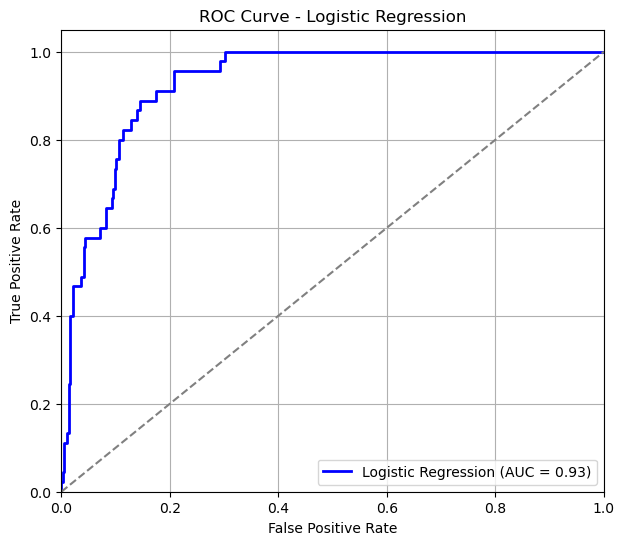

In [25]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# AUC-ROC curve between Logistic Regression and Decision Tree 

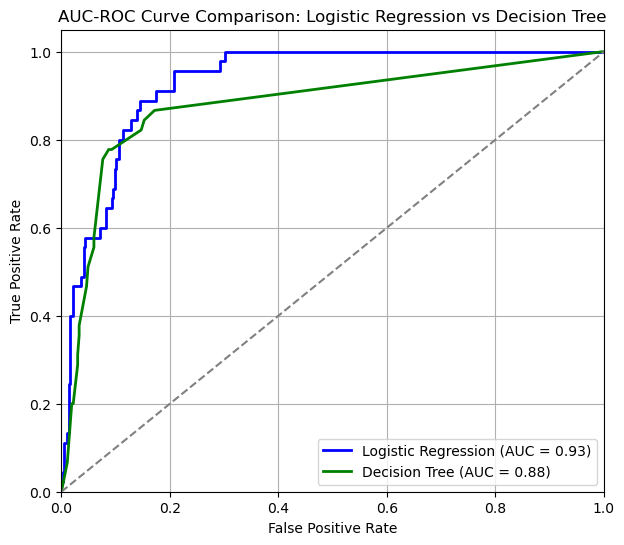

In [26]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree (AUC = {auc_dt:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('AUC-ROC Curve Comparison: Logistic Regression vs Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Hyperparameter tuning and applying SMOTE on the previous Midterm work

### Logistic Regression pipeline and tuning 

In [27]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 5, 10],
    'lr__solver': ['lbfgs', 'liblinear'],
    'lr__penalty': ['l2']
}

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=10,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)



Fitting 10 folds for each of 10 candidates, totalling 100 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lr',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.01, 0.1, 1, 5, 10], 'lr__penalty': ['l2'],
                         'lr__solver': ['lbfgs', 'liblinear']},
             scoring='recall', verbose=1)

In [28]:
print(f'Best C: {grid_lr.best_params_["lr__C"]}')
print(f'Best Solver: {grid_lr.best_params_["lr__solver"]}')
print(f'Best Penalty: {grid_lr.best_params_["lr__penalty"]}')

Best C: 5
Best Solver: lbfgs
Best Penalty: l2


In [29]:
y_pred_lr_hyper = grid_lr.predict(X_test)

In [30]:
y_prob_lr_hyper = grid_lr.predict_proba(X_test)[:, 1]

In [31]:
cm_lr_hyper = confusion_matrix(y_test, y_pred_lr_hyper)

In [32]:
evaluate_results("Logistic Regression with Hyperparameter Tuning", y_test, y_pred_lr_hyper, y_prob_lr_hyper, cm_lr_hyper)


Logistic Regression with Hyperparameter Tuning Evaluation
---------------------------------------------------------
Accuracy     : 91.99%
Precision    : 75.00%
Recall       : 40.00%
F1 Score     : 52.17%
AUC Score    : 92.98%
Confusion Matrix:
[[361   6]
 [ 27  18]]

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.98      0.96       367
         Yes       0.75      0.40      0.52        45

    accuracy                           0.92       412
   macro avg       0.84      0.69      0.74       412
weighted avg       0.91      0.92      0.91       412



### Logistic Regression pipeline and tuning with SMOTE

In [33]:
log_reg_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('logreg', LogisticRegression(max_iter=1000))
])

log_reg_params = {
    'logreg__C': [0.01, 0.1, 1, 5, 10],
    'logreg__solver': ['lbfgs', 'liblinear'],
    'logreg__penalty': ['l2']
}

grid_log = GridSearchCV(
    estimator=log_reg_pipe,
    param_grid=log_reg_params,
    cv=10,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_log.fit(X_train, y_train)

print("Best Logistic Regression Params:", grid_log.best_params_)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best Logistic Regression Params: {'logreg__C': 0.01, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}


In [34]:
# Make predictions with the best Logistic Regression model
y_pred_bestlr = grid_log.predict(X_test)

In [35]:
# Get predicted probabilities for Logistic Regression
y_prob_bestlr = grid_log.predict_proba(X_test)[:, 1]

In [36]:
# Calculate confusion matrix
cm_bestlr = confusion_matrix(y_test, y_pred_bestlr)

### Results Logistic Regression

In [37]:
evaluate_results("Logistic Regression with SMOTE", y_test, y_pred_bestlr, y_prob_bestlr, cm_bestlr)


Logistic Regression with SMOTE Evaluation
-----------------------------------------
Accuracy     : 87.14%
Precision    : 45.45%
Recall       : 88.89%
F1 Score     : 60.15%
AUC Score    : 94.28%
Confusion Matrix:
[[319  48]
 [  5  40]]

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.87      0.92       367
         Yes       0.45      0.89      0.60        45

    accuracy                           0.87       412
   macro avg       0.72      0.88      0.76       412
weighted avg       0.93      0.87      0.89       412



### Decision Tree pipeline and tuning 

In [38]:
pipe_dt =Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'dt__max_depth': [3, 5, 7, 10, None],
    'dt__min_samples_split': [2, 5, 10, 20],
    'dt__min_samples_leaf': [1, 2, 4, 8],
    'dt__criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid_dt,
    cv=10,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print("Best Decision Tree Params:", grid_dt.best_params_)


Fitting 10 folds for each of 160 candidates, totalling 1600 fits
Best Decision Tree Params: {'dt__criterion': 'gini', 'dt__max_depth': 3, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}


In [39]:
print("Best max_depth:", grid_dt.best_params_['dt__max_depth'])
print("Best min_samples_split:", grid_dt.best_params_['dt__min_samples_split'])
print("Best min_samples_leaf:", grid_dt.best_params_['dt__min_samples_leaf'])
print("Best criterion:", grid_dt.best_params_['dt__criterion'])

Best max_depth: 3
Best min_samples_split: 2
Best min_samples_leaf: 1
Best criterion: gini


In [40]:
y_pred_dt_hyper = grid_dt.predict(X_test)

In [41]:
y_prob_dt_hyper = grid_dt.predict_proba(X_test)[:, 1]

In [42]:
cm_dt_hyper = confusion_matrix(y_test, y_pred_dt_hyper)

In [43]:
evaluate_results("Decision Tree with Hyperparameter Tuning", y_test, y_pred_dt_hyper, y_prob_dt_hyper, cm_dt_hyper)


Decision Tree with Hyperparameter Tuning Evaluation
---------------------------------------------------
Accuracy     : 89.56%
Precision    : 52.38%
Recall       : 48.89%
F1 Score     : 50.57%
AUC Score    : 85.76%
Confusion Matrix:
[[347  20]
 [ 23  22]]

Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.95      0.94       367
         Yes       0.52      0.49      0.51        45

    accuracy                           0.90       412
   macro avg       0.73      0.72      0.72       412
weighted avg       0.89      0.90      0.89       412



### Decision Tree pipeline and tuning with SMOTE

In [44]:
tree_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('tree', DecisionTreeClassifier(random_state=42))
])

tree_params = {
    'tree__max_depth': [3, 5, 7, 10, None],
    'tree__min_samples_split': [2, 5, 10, 20],
    'tree__min_samples_leaf': [1, 2, 4, 8],
    'tree__criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(
    estimator=tree_pipe,
    param_grid=tree_params,
    cv=10,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_tree.fit(X_train, y_train)

print("Best Decision Tree Params:", grid_tree.best_params_)

Fitting 10 folds for each of 160 candidates, totalling 1600 fits
Best Decision Tree Params: {'tree__criterion': 'gini', 'tree__max_depth': 3, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [45]:
# Make predictions with the best Decision Tree model
y_pred_bestdt = grid_tree.predict(X_test)

In [46]:
# Get predicted probabilities for Decision Tree
y_prob_bestdt = grid_tree.predict_proba(X_test)[:, 1]

In [47]:
# Calculate confusion matrix
cm_bestdt = confusion_matrix(y_test, y_pred_bestdt)

### Results Decision Tree

In [48]:
evaluate_results("Decision Tree with SMOTE", y_test, y_pred_bestdt, y_prob_bestdt, cm_bestdt)


Decision Tree with SMOTE Evaluation
-----------------------------------
Accuracy     : 87.62%
Precision    : 46.25%
Recall       : 82.22%
F1 Score     : 59.20%
AUC Score    : 89.33%
Confusion Matrix:
[[324  43]
 [  8  37]]

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.88      0.93       367
         Yes       0.46      0.82      0.59        45

    accuracy                           0.88       412
   macro avg       0.72      0.85      0.76       412
weighted avg       0.92      0.88      0.89       412



# Adding Support Vector Machine(SVM) to reproduce in the research paper 

In [49]:
# Create SVM pipeline
pipe_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True, random_state=42))
])

In [50]:
# Define parameter grid for SVC
param_grid_svc = {
    'svc__C': [1, 10, 100],
    'svc__kernel': ['rbf', 'linear']
}

In [51]:
# Set up GridSearchCV for SVC
grid_svc = GridSearchCV(
    pipe_svc,
    param_grid_svc,
    cv=10,
    scoring='recall',
    n_jobs=-1
)

In [52]:
# Fit the GridSearchCV
grid_svc.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc',
                                        SVC(probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'svc__C': [1, 10, 100],
                         'svc__kernel': ['rbf', 'linear']},
             scoring='recall')

In [53]:
# Best parameters and best score for SVC
print(f"Best C:" , grid_svc.best_params_['svc__C'])
print(f"Best Kernel:" , grid_svc.best_params_['svc__kernel'])
print("Best CV Accuracy:" , grid_svc.best_score_)

Best C: 10
Best Kernel: rbf
Best CV Accuracy: 0.45579268292682923


In [54]:
# Make predictions with the best SVC model
y_pred_svc = grid_svc.predict(X_test)

In [55]:
# Get predicted probabilities for SVC
y_prob_svc = grid_svc.predict_proba(X_test)[:, 1]


In [56]:
# Calculate confusion matrix
cm_svc = confusion_matrix(y_test, y_pred_svc)

In [57]:
# Evaluate the SVC results
evaluate_results("SVC", y_test, y_pred_svc, y_prob_svc, cm_svc)


SVC Evaluation
--------------
Accuracy     : 89.56%
Precision    : 53.12%
Recall       : 37.78%
F1 Score     : 44.16%
AUC Score    : 87.93%
Confusion Matrix:
[[352  15]
 [ 28  17]]

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.96      0.94       367
         Yes       0.53      0.38      0.44        45

    accuracy                           0.90       412
   macro avg       0.73      0.67      0.69       412
weighted avg       0.88      0.90      0.89       412



# Adding different classification models: K-Nearest Neighbors(KNN)

In [58]:
# Create KNN pipeline
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

In [59]:
# Define parameter grid for KNN
param_grid_knn = {
    'knn__n_neighbors':list(range(1,36))
}


In [60]:
# Set up GridSearchCV for KNN
grid_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=10,
    scoring='recall',
    n_jobs=-1
)

In [61]:
# Fit the KNN model
grid_knn.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29, 30, ...]},
             scoring='recall')

In [62]:
# Print best parameters and best score for KNN
print(f"Best K:" , grid_knn.best_params_['knn__n_neighbors'])
print("Best CV Accuracy:" , grid_knn.best_score_)

Best K: 1
Best CV Accuracy: 0.3199390243902439


In [63]:
# Make predictions with the best KNN model
y_pred_knn = grid_knn.predict(X_test)


In [64]:
# Get predicted probabilities for KNN
y_prob_knn = grid_knn.predict_proba(X_test)[:, 1]

In [65]:
# Calculate confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

In [66]:
# Evaluate the KNN results
evaluate_results("KNN", y_test, y_pred_knn, y_prob_knn, cm_knn)


KNN Evaluation
--------------
Accuracy     : 85.92%
Precision    : 32.43%
Recall       : 26.67%
F1 Score     : 29.27%
AUC Score    : 59.93%
Confusion Matrix:
[[342  25]
 [ 33  12]]

Classification Report:
              precision    recall  f1-score   support

          No       0.91      0.93      0.92       367
         Yes       0.32      0.27      0.29        45

    accuracy                           0.86       412
   macro avg       0.62      0.60      0.61       412
weighted avg       0.85      0.86      0.85       412



# Adding different classification models: Neural Network

In [67]:
# Pipeline for Neural Network
pipe_nn = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', MLPClassifier(
        max_iter=500,
        random_state=42))
])

In [68]:
# Define parameter grid for Neural Network
param_grid_nn = {
    'nn__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'nn__activation': ['relu', 'tanh'],
    'nn__solver': ['adam'],
    'nn__alpha': [0.0001, 0.001],
    'nn__learning_rate_init': [0.001],
}


In [69]:
# Define GridSearchCV for Neural Network
grid_nn = GridSearchCV(
    pipe_nn,
    param_grid_nn,
    cv=10,
    scoring='recall',
    n_jobs=-1
)

In [70]:
grid_nn.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('nn',
                                        MLPClassifier(max_iter=500,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'nn__activation': ['relu', 'tanh'],
                         'nn__alpha': [0.0001, 0.001],
                         'nn__hidden_layer_sizes': [(50,), (100,), (50, 50)],
                         'nn__learning_rate_init': [0.001],
                         'nn__solver': ['adam']},
             scoring='recall')

In [71]:
# Best parameters and best score for Neural Network
print("Best hidden_layer_sizes:" , grid_nn.best_params_['nn__hidden_layer_sizes'])
print("Best activation:" , grid_nn.best_params_['nn__activation'])
print("Best solver:" , grid_nn.best_params_['nn__solver'])
print("Best alpha:" , grid_nn.best_params_['nn__alpha'])
print("Best learning_rate_init:" , grid_nn.best_params_['nn__learning_rate_init'])
print("Best CV Accuracy:" , grid_nn.best_score_)

Best hidden_layer_sizes: (50,)
Best activation: relu
Best solver: adam
Best alpha: 0.0001
Best learning_rate_init: 0.001
Best CV Accuracy: 0.48774390243902443


In [72]:
# Test the Neural Network model
y_pred_nn = grid_nn.predict(X_test)

In [73]:
# Get predicted probabilities for Neural Network
y_prob_nn = grid_nn.predict_proba(X_test)[:, 1]

In [74]:
# Calculate confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)

In [75]:
# Evaluate the Neural Network results
evaluate_results("Neural Network", y_test, y_pred_nn, y_prob_nn, cm_nn)


Neural Network Evaluation
-------------------------
Accuracy     : 88.83%
Precision    : 48.39%
Recall       : 33.33%
F1 Score     : 39.47%
AUC Score    : 82.10%
Confusion Matrix:
[[351  16]
 [ 30  15]]

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.96      0.94       367
         Yes       0.48      0.33      0.39        45

    accuracy                           0.89       412
   macro avg       0.70      0.64      0.67       412
weighted avg       0.87      0.89      0.88       412



# AUC-ROC curve between Logistic Regression,Decision Tree,SVM,KNN and Neural Network

In [76]:
y_prob_lr_hyper = grid_lr.predict_proba(X_test)[:, 1]
y_prob_dt_hyper = grid_dt.predict_proba(X_test)[:, 1]
y_prob_svc = grid_svc.predict_proba(X_test)[:, 1]
y_prob_knn = grid_knn.predict_proba(X_test)[:, 1]
y_prob_nn = grid_nn.predict_proba(X_test)[:, 1]

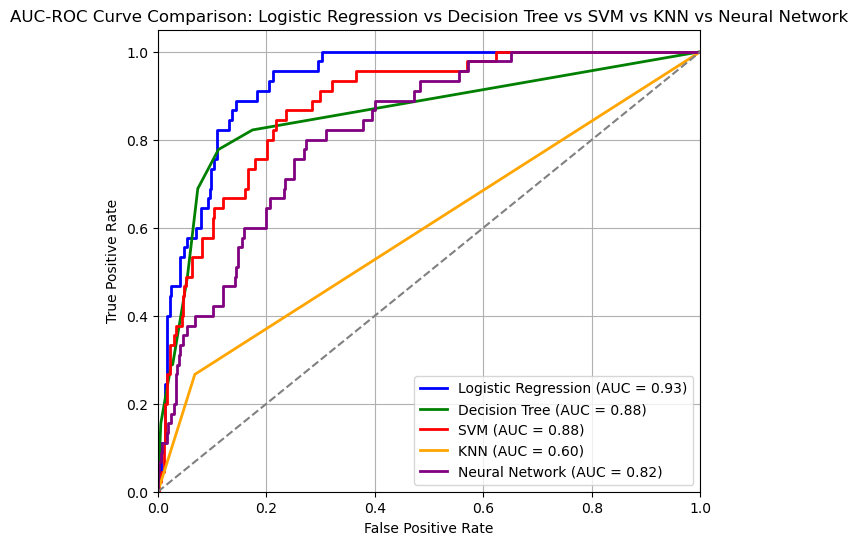

In [77]:
# Compare the ROC curves of Logistic Regression, Decision Tree, SVC, KNN and Neural Network

fpr_lr_hyper, tpr_lr_hyper, _ = roc_curve(y_test, y_prob_lr_hyper)
auc_lr_hyper = roc_auc_score(y_test, y_prob_lr_hyper)

fpr_dt_hyper, tpr_dt_hyper, _ = roc_curve(y_test, y_prob_dt_hyper)
auc_dt_hyper = roc_auc_score(y_test, y_prob_dt_hyper)

fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)
auc_svc = roc_auc_score(y_test, y_prob_svc)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = roc_auc_score(y_test, y_prob_nn)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr_hyper, tpr_lr_hyper, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt_hyper, tpr_dt_hyper, color='green', lw=2, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_svc, tpr_svc, color='red', lw=2, label=f'SVM (AUC = {auc_svc:.2f})')
plt.plot(fpr_knn, tpr_knn, color='orange', lw=2, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_nn, tpr_nn, color='purple', lw=2, label=f'Neural Network (AUC = {auc_nn:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('AUC-ROC Curve Comparison: Logistic Regression vs Decision Tree vs SVM vs KNN vs Neural Network')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Adding Support Vector Machine(SVM) with SMOTE

In [78]:
# Split the training data for SMOTE
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [79]:
# Create a pipeline for SVC with SMOTE
pipe_svc_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(probability=True, random_state=42)),
])

In [80]:
# Define parameter grid for SVC with SMOTE
param_grid_svc_smote = {
    'svc__C': [1, 10, 100],
    'svc__kernel': ['rbf', 'linear'],
    'smote__k_neighbors': [5, 10, 15]
}

In [81]:
# Set up GridSearchCV for SVC with SMOTE 
grid_svc_smote = GridSearchCV(
    pipe_svc_smote,
    param_grid_svc_smote,
    cv=10,
    scoring='recall',
    n_jobs=-1
)

In [82]:
# Fit the SVC model with SMOTE
grid_svc_smote.fit(X_train_small, y_train_small)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('svc',
                                        SVC(probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'smote__k_neighbors': [5, 10, 15],
                         'svc__C': [1, 10, 100],
                         'svc__kernel': ['rbf', 'linear']},
             scoring='recall')

In [83]:
# Get best parameters for SVC with SMOTE
best_c_smote = grid_svc_smote.best_params_['svc__C']
best_kernel_smote = grid_svc_smote.best_params_['svc__kernel']
best_k_neighbors_svc_smote = grid_svc_smote.best_params_['smote__k_neighbors']

grid_svc_best_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(k_neighbors=best_k_neighbors_svc_smote, random_state=42)),
    ('svc', SVC(C=best_c_smote, kernel=best_kernel_smote, probability=True, random_state=42))
])


In [84]:
# Fit the best SVC model with SMOTE
grid_svc_best_smote.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTE(k_neighbors=10, random_state=42)),
                ('svc',
                 SVC(C=10, kernel='linear', probability=True,
                     random_state=42))])

In [85]:
# Best parameters and best score for SVC with SMOTE
print("Best C:", grid_svc_best_smote.named_steps['svc'].C)
print("Best Kernel:", grid_svc_best_smote.named_steps['svc'].kernel)
print("Best SMOTE k_neighbors:", grid_svc_best_smote.named_steps['smote'].k_neighbors)

Best C: 10
Best Kernel: linear
Best SMOTE k_neighbors: 10


In [86]:
# Make predictions with the best SVC model with SMOTE
y_pred_svc_smote = grid_svc_best_smote.predict(X_test)

In [87]:
# Get predicted probabilities for SVC with SMOTE
y_prob_svc_smote = grid_svc_best_smote.predict_proba(X_test)[:, 1]

In [88]:
# Calculate confusion matrix for SVC with SMOTE
cm_svc_smote = confusion_matrix(y_test, y_pred_svc_smote)

In [89]:
# Evaluate the SVC results
evaluate_results("SVC with SMOTE", y_test, y_pred_svc_smote, y_prob_svc_smote, cm_svc_smote)


SVC with SMOTE Evaluation
-------------------------
Accuracy     : 84.95%
Precision    : 40.86%
Recall       : 84.44%
F1 Score     : 55.07%
AUC Score    : 92.98%
Confusion Matrix:
[[312  55]
 [  7  38]]

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.85      0.91       367
         Yes       0.41      0.84      0.55        45

    accuracy                           0.85       412
   macro avg       0.69      0.85      0.73       412
weighted avg       0.92      0.85      0.87       412



# Adding K-Nearest Neighbors(KNN) with SMOTE

In [90]:
# Create KNN pipeline with SMOTE
pipe_knn_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

In [91]:
# Define parameter grid for KNN with SMOTE
param_grid_knn_smote = {
    'knn__n_neighbors':list(range(1,36)),
    'smote__k_neighbors': [5, 10, 15]
}

In [92]:
# Set up GridSearchCV for KNN with SMOTE
grid_knn_smote = GridSearchCV(
    pipe_knn_smote,
    param_grid_knn_smote,
    cv=10,
    scoring='recall',
    n_jobs=-1
)

In [93]:
# Fit the KNN model
grid_knn_smote.fit(X_train_small, y_train_small)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29, 30, ...],
                         'smote__k_neighbors': [5, 10, 15]},
             scoring='recall')

In [94]:
# Get best parameters for KNN with SMOTE
best_k_smote = grid_knn_smote.best_params_['knn__n_neighbors']
best_k_neighbors_knn_smote = grid_knn_smote.best_params_['smote__k_neighbors']

grid_knn_best_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(k_neighbors=best_k_neighbors_knn_smote, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k_smote))
])

In [95]:
# Fit the best KNN model with SMOTE
grid_knn_best_smote.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('knn', KNeighborsClassifier(n_neighbors=35))])

In [96]:
# Print best parameters and best score for KNN with SMOTE
print(f"Best K:", grid_knn_best_smote.named_steps['knn'].n_neighbors)
print("Best K for SMOTE:", grid_knn_best_smote.named_steps['smote'].k_neighbors)

Best K: 35
Best K for SMOTE: 5


In [97]:
# Make predictions with the best KNN model with SMOTE
y_pred_knn_smote = grid_knn_best_smote.predict(X_test)

In [98]:
# Get predicted probabilities for KNN with SMOTE
y_prob_knn_smote = grid_knn_best_smote.predict_proba(X_test)[:, 1]

In [99]:
# Calculate confusion matrix
cm_knn_smote = confusion_matrix(y_test, y_pred_knn_smote)

In [100]:
# Evaluate the KNN results with SMOTE
evaluate_results("KNN with SMOTE", y_test, y_pred_knn_smote, y_prob_knn_smote, cm_knn_smote)



KNN with SMOTE Evaluation
-------------------------
Accuracy     : 79.61%
Precision    : 33.04%
Recall       : 84.44%
F1 Score     : 47.50%
AUC Score    : 82.47%
Confusion Matrix:
[[290  77]
 [  7  38]]

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.79      0.87       367
         Yes       0.33      0.84      0.47        45

    accuracy                           0.80       412
   macro avg       0.65      0.82      0.67       412
weighted avg       0.91      0.80      0.83       412



# Adding Neural Network with SMOTE

In [101]:
# Pipeline for Neural Network with SMOTE
pipe_nn_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('nn', MLPClassifier(
        max_iter=500,
        random_state=42))
])

In [102]:
# Define parameter grid for Neural Network with SMOTE
param_grid_nn_smote = {
    'nn__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'nn__activation': ['relu', 'tanh'],
    'nn__solver': ['adam'],
    'nn__alpha': [0.0001, 0.001],
    'nn__learning_rate_init': [0.001],
    'smote__k_neighbors': [5, 10, 15]
}

In [103]:
# Define GridSearchCV for Neural Network with SMOTE
grid_nn_smote = GridSearchCV(
    pipe_nn_smote,
    param_grid_nn_smote,
    cv=10,
    scoring='recall',
    n_jobs=-1
)

In [104]:
# Fit the Neural Network model with SMOTE
grid_nn_smote.fit(X_train_small, y_train_small)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('nn',
                                        MLPClassifier(max_iter=500,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'nn__activation': ['relu', 'tanh'],
                         'nn__alpha': [0.0001, 0.001],
                         'nn__hidden_layer_sizes': [(50,), (100,), (50, 50)],
                         'nn__learning_rate_init': [0.001],
                         'nn__solver': ['adam'],
                         'smote__k_neighbors': [5, 10, 15]},
             scoring='recall')

In [105]:
# Get best parameters for Neural Network with SMOTE
best_hidden_layer_sizes_smote = grid_nn_smote.best_params_['nn__hidden_layer_sizes']
best_activation_smote = grid_nn_smote.best_params_['nn__activation']
best_solver_smote = grid_nn_smote.best_params_['nn__solver']
best_alpha_smote = grid_nn_smote.best_params_['nn__alpha']
best_learning_rate_init_smote = grid_nn_smote.best_params_['nn__learning_rate_init']
best_k_neighbors_nn_smote = grid_nn_smote.best_params_['smote__k_neighbors']

grid_nn_best_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(k_neighbors=best_k_neighbors_nn_smote, random_state=42)),
    ('nn', MLPClassifier(
        hidden_layer_sizes=best_hidden_layer_sizes_smote,
        activation=best_activation_smote,
        solver=best_solver_smote,
        alpha=best_alpha_smote,
        learning_rate_init=best_learning_rate_init_smote,
        max_iter=500,
        random_state=42
    ))
])

In [106]:
# Fit the best Neural Network model with SMOTE
grid_nn_best_smote.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTE(k_neighbors=15, random_state=42)),
                ('nn',
                 MLPClassifier(activation='tanh', max_iter=500,
                               random_state=42))])

In [107]:
# Best parameters and best score for Neural Network with SMOTE
print("Best hidden_layer_sizes:" , grid_nn_best_smote.named_steps['nn'].hidden_layer_sizes)
print("Best activation:" , grid_nn_best_smote.named_steps['nn'].activation)
print("Best solver:" , grid_nn_best_smote.named_steps['nn'].solver)
print("Best alpha:" , grid_nn_best_smote.named_steps['nn'].alpha)
print("Best learning_rate_init:" , grid_nn_best_smote.named_steps['nn'].learning_rate_init)
print("Best K for SMOTE:", grid_nn_best_smote.named_steps['smote'].k_neighbors)


Best hidden_layer_sizes: (100,)
Best activation: tanh
Best solver: adam
Best alpha: 0.0001
Best learning_rate_init: 0.001
Best K for SMOTE: 15


In [108]:
# Test the Neural Network model with SMOTE
y_pred_nn_smote = grid_nn_best_smote.predict(X_test)

In [109]:
# Get predicted probabilities for Neural Network with SMOTE
y_prob_nn_smote = grid_nn_best_smote.predict_proba(X_test)[:, 1]

In [110]:
# Calculate confusion matrix for Neural Network with SMOTE
cm_nn_smote = confusion_matrix(y_test, y_pred_nn_smote)

In [111]:
# Evaluate the Neural Network results with SMOTE
evaluate_results("Neural Network with SMOTE", y_test, y_pred_nn_smote, y_prob_nn_smote, cm_nn_smote)


Neural Network with SMOTE Evaluation
------------------------------------
Accuracy     : 88.35%
Precision    : 47.17%
Recall       : 55.56%
F1 Score     : 51.02%
AUC Score    : 90.48%
Confusion Matrix:
[[339  28]
 [ 20  25]]

Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.92      0.93       367
         Yes       0.47      0.56      0.51        45

    accuracy                           0.88       412
   macro avg       0.71      0.74      0.72       412
weighted avg       0.89      0.88      0.89       412



# AUC-ROC curve between SVM,KNN and Neural Network

In [112]:
y_prob_svc = grid_svc.predict_proba(X_test)[:, 1]
y_prob_knn = grid_knn.predict_proba(X_test)[:, 1]
y_prob_nn = grid_nn.predict_proba(X_test)[:, 1]

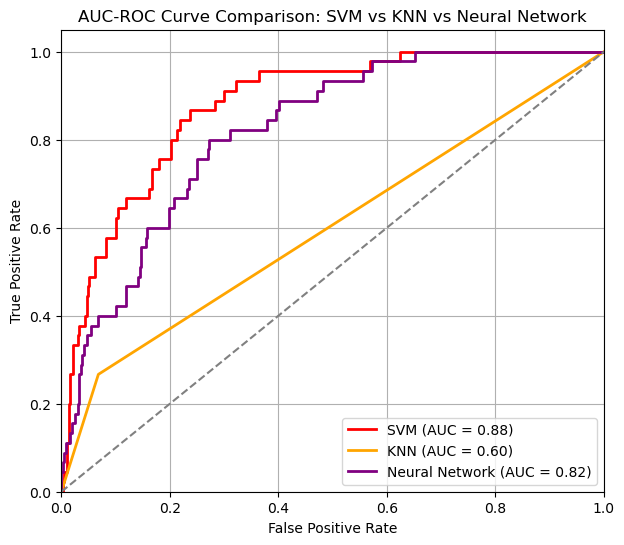

In [113]:
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)
auc_svc = roc_auc_score(y_test, y_prob_svc)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = roc_auc_score(y_test, y_prob_nn)

plt.figure(figsize=(7, 6))

plt.plot(fpr_svc, tpr_svc, color='red', lw=2, label=f'SVM (AUC = {auc_svc:.2f})')
plt.plot(fpr_knn, tpr_knn, color='orange', lw=2, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_nn, tpr_nn, color='purple', lw=2, label=f'Neural Network (AUC = {auc_nn:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('AUC-ROC Curve Comparison: SVM vs KNN vs Neural Network')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# AUC-ROC curve between SVM,KNN and Neural Network with SMOTE

In [114]:
y_prob_svc_smote = grid_svc_best_smote.predict_proba(X_test)[:, 1]
y_prob_knn_smote = grid_knn_best_smote.predict_proba(X_test)[:, 1]
y_prob_nn_smote = grid_nn_best_smote.predict_proba(X_test)[:, 1]

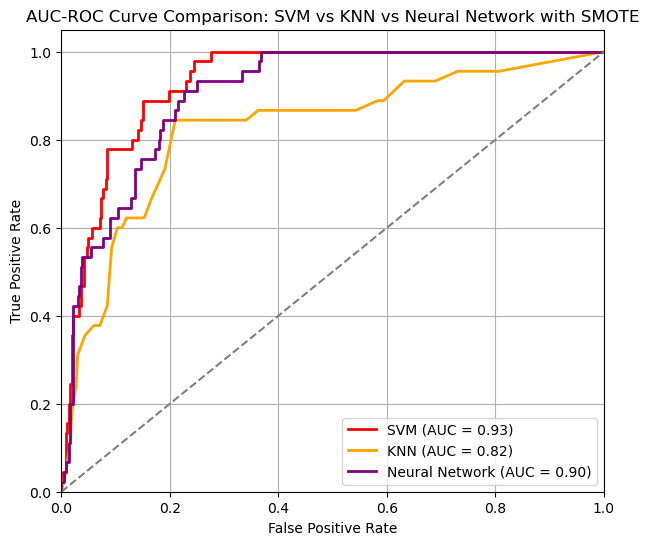

In [115]:
fpr_svc_smote, tpr_svc_smote, _ = roc_curve(y_test, y_prob_svc_smote)
auc_svc_smote = roc_auc_score(y_test, y_prob_svc_smote)

fpr_knn_smote, tpr_knn_smote, _ = roc_curve(y_test, y_prob_knn_smote)
auc_knn_smote = roc_auc_score(y_test, y_prob_knn_smote)

fpr_nn_smote, tpr_nn_smote, _ = roc_curve(y_test, y_prob_nn_smote)
auc_nn_smote = roc_auc_score(y_test, y_prob_nn_smote)

plt.figure(figsize=(7, 6))

plt.plot(fpr_svc_smote, tpr_svc_smote, color='red', lw=2, label=f'SVM (AUC = {auc_svc_smote:.2f})')
plt.plot(fpr_knn_smote, tpr_knn_smote, color='orange', lw=2, label=f'KNN (AUC = {auc_knn_smote:.2f})')
plt.plot(fpr_nn_smote, tpr_nn_smote, color='purple', lw=2, label=f'Neural Network (AUC = {auc_nn_smote:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('AUC-ROC Curve Comparison: SVM vs KNN vs Neural Network with SMOTE')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# AUC-ROC curve between Logistic Regression,Decision Tree,SVM,KNN and Neural Network with SMOTE

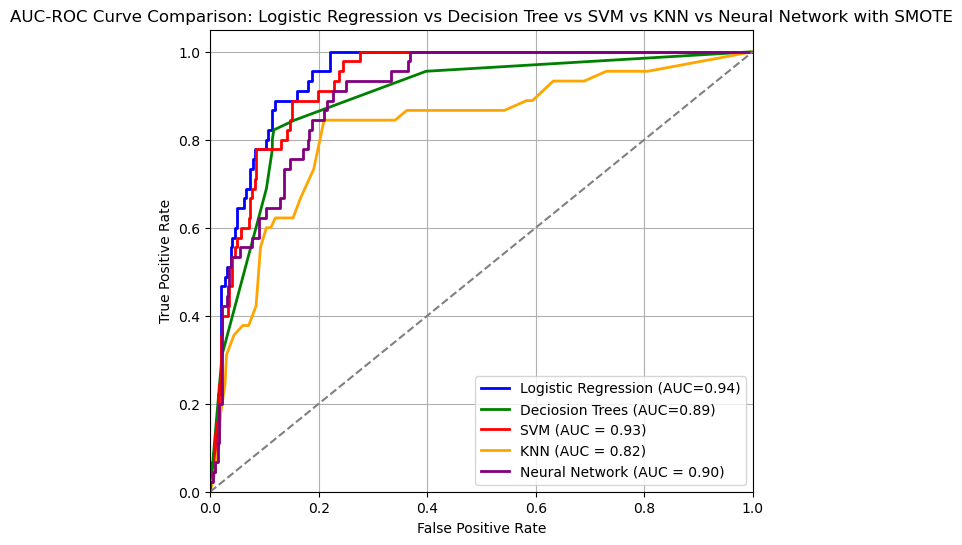

In [116]:
# Compare the ROC curves of Logistic Regression, Decision Tree, SVC, KNN and Neural Network with SMOTE

fpr_lr_smote, tpr_lr_smote, _ = roc_curve(y_test, y_prob_bestlr)
auc_lr_smote = roc_auc_score(y_test, y_prob_bestlr)

fpr_dt_smote, tpr_dt_smote, _ = roc_curve(y_test, y_prob_bestdt)
auc_dt_smote = roc_auc_score(y_test, y_prob_bestdt)

fpr_svc_smote, tpr_svc_smote, _ = roc_curve(y_test, y_prob_svc_smote)
auc_svc_smote = roc_auc_score(y_test, y_prob_svc_smote)

fpr_knn_smote, tpr_knn_smote, _ = roc_curve(y_test, y_prob_knn_smote)
auc_knn_smote = roc_auc_score(y_test, y_prob_knn_smote)

fpr_nn_smote, tpr_nn_smote, _ = roc_curve(y_test, y_prob_nn_smote)
auc_nn_smote = roc_auc_score(y_test, y_prob_nn_smote)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr_smote, tpr_lr_smote, color='blue', lw=2, label=f'Logistic Regression (AUC={auc_lr_smote:.2f})')
plt.plot(fpr_dt_smote, tpr_dt_smote, color='green', lw=2, label=f'Deciosion Trees (AUC={auc_dt_smote:.2f})')
plt.plot(fpr_svc_smote, tpr_svc_smote, color='red', lw=2, label=f'SVM (AUC = {auc_svc_smote:.2f})')
plt.plot(fpr_knn_smote, tpr_knn_smote, color='orange', lw=2, label=f'KNN (AUC = {auc_knn_smote:.2f})')
plt.plot(fpr_nn_smote, tpr_nn_smote, color='purple', lw=2, label=f'Neural Network (AUC = {auc_nn_smote:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('AUC-ROC Curve Comparison: Logistic Regression vs Decision Tree vs SVM vs KNN vs Neural Network with SMOTE')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [117]:
print(f"Accuracy of Logistic Regression     : {accuracy_score(y_test, y_pred_lr_hyper):.2%}")
print(f"Accuracy of Decision Tree           : {accuracy_score(y_test, y_pred_dt_hyper):.2%}")
print(f"Accuracy of Support Vector Machine  : {accuracy_score(y_test, y_pred_svc):.2%}")
print(f"Accuracy of KNN                    : {accuracy_score(y_test, y_pred_knn):.2%}")
print(f"Accuracy of Neural Network         : {accuracy_score(y_test, y_pred_nn):.2%}")

Accuracy of Logistic Regression     : 91.99%
Accuracy of Decision Tree           : 89.56%
Accuracy of Support Vector Machine  : 89.56%
Accuracy of KNN                    : 85.92%
Accuracy of Neural Network         : 88.83%


In [118]:
print(f"Accuracy of Logistic Regression with SMOTE: {accuracy_score(y_test, y_pred_bestlr):.2%}")
print(f"Accuracy of Decision Tree with SMOTE: {accuracy_score(y_test, y_pred_bestdt):.2%}")
print(f"Accuracy of SVC with SMOTE            : {accuracy_score(y_test, y_pred_svc_smote):.2%}")
print(f"Accuracy of KNN with SMOTE            : {accuracy_score(y_test, y_pred_knn_smote):.2%}")
print(f"Accuracy of Neural Network with SMOTE : {accuracy_score(y_test, y_pred_nn_smote):.2%}")

Accuracy of Logistic Regression with SMOTE: 87.14%
Accuracy of Decision Tree with SMOTE: 87.62%
Accuracy of SVC with SMOTE            : 84.95%
Accuracy of KNN with SMOTE            : 79.61%
Accuracy of Neural Network with SMOTE : 88.35%
